In [1]:
import pandas as pd
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from collections import deque

<h2>IPL 2026 Matches Data Extracted from EspnCricInfo</h2>
<b>Total 48/70 matches completed during the time of this simulation</b>
<table border="1" cellpadding="8" cellspacing="0">
    <thead>
        <tr>
            <th>Attribute</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>match_id</td>
            <td>Unique identifier for each match</td>
        </tr>
        <tr>
            <td>date</td>
            <td>Date on which the match was played</td>
        </tr>
        <tr>
            <td>venue</td>
            <td>Stadium or venue where the match took place</td>
        </tr>
        <tr>
            <td>team1</td>
            <td>Name of the first team</td>
        </tr>
        <tr>
            <td>team2</td>
            <td>Name of the second team</td>
        </tr>
        <tr>
            <td>stage</td>
            <td>Tournament stage (League, Qualifier, Eliminator, Final, etc.)</td>
        </tr>
        <tr>
            <td>toss_winner</td>
            <td>Team that won the toss</td>
        </tr>
        <tr>
            <td>toss_decision</td>
            <td>Decision taken after winning the toss (Bat/Bowl)</td>
        </tr>
        <tr>
            <td>first_ings_score</td>
            <td>Total runs scored in the first innings</td>
        </tr>
        <tr>
            <td>first_ings_wkts</td>
            <td>Wickets lost in the first innings</td>
        </tr>
        <tr>
            <td>second_ings_score</td>
            <td>Total runs scored in the second innings</td>
        </tr>
        <tr>
            <td>second_ings_wkts</td>
            <td>Wickets lost in the second innings</td>
        </tr>
        <tr>
            <td>match_result</td>
            <td>Result summary of the match</td>
        </tr>
        <tr>
            <td>match_winner</td>
            <td>Winning team of the match</td>
        </tr>
        <tr>
            <td>wb_runs</td>
            <td>Winning margin in terms of runs</td>
        </tr>
        <tr>
            <td>wb_wickets</td>
            <td>Winning margin in terms of wickets</td>
        </tr>
        <tr>
            <td>balls_left</td>
            <td>Number of balls remaining at the end of the chase</td>
        </tr>
        <tr>
            <td>super_over_match</td>
            <td>Indicates whether the match went to a Super Over (Yes/No)</td>
        </tr>
    </tbody>
</table>

In [2]:
matches_df = pd.read_csv("matches.csv")

In [3]:
# Number of recent matches considered while calculating team momentum/form streak
STREAK_WINDOW = 3

# Elo rating adjustment factor:
# Higher value = ratings change more aggressively after each match
K_FACTOR = 32

# Total Monte Carlo simulations used for the playoff prediction
SIMULATIONS = 50000

# Additional Elo points awarded to a team playing at its home ground
HOME_ADVANTAGE = 60

# Extra Elo boost given to the toss-winning team
TOSS_BOOST = 25


# Mapping of IPL teams to their designated home venues, one team can have multiple home grounds during the season
HOME_GROUNDS = {
    "RCB": ["M. Chinnaswamy Stadium, Bangalore", "Veer Narayan Singh Stadium, Raipur"],
    "MI": ["Wankhede Stadium, Mumbai"],
    "CSK": ["MA Chidambaram Stadium, Chennai"],
    "DC": ["Arun Jaitley Stadium, Delhi"],
    "SRH": ["Rajiv Gandhi International Stadium, Hyderabad"],
    "KKR": ["Eden Gardens, Kolkata"],
    "LSG": ["Ekana Cricket Stadium, Lucknow"],
    "PBKS": ["New PCA Cricket Stadium, Mullanpur", "Himachal Pradesh Stadium, Dharamshala"],
    "GT": ["Narendra Modi Stadium, Ahmedabad"],
    "RR": ["Barsapara Stadium, Guwahati", "Sawai Mansingh Stadium, Jaipur"]
}


# Average first innings score at each venue, used to estimate pitch behavior and scoring conditions
VENUE_MEANS = { 
    "M. Chinnaswamy Stadium, Bangalore": 190,
    "Wankhede Stadium, Mumbai": 195,
    "Barsapara Stadium, Guwahati": 172,
    "New PCA Cricket Stadium, Mullanpur": 203,
    "Ekana Cricket Stadium, Lucknow": 194,
    "Eden Gardens, Kolkata": 187,
    "MA Chidambaram Stadium, Chennai": 187,
    "Arun Jaitley Stadium, Delhi": 193,
    "Narendra Modi Stadium, Ahmedabad": 200,
    "Rajiv Gandhi International Stadium, Hyderabad": 187,
    "Sawai Mansingh Stadium, Jaipur": 189,
    "Veer Narayan Singh Stadium, Raipur": 168,
    "Himachal Pradesh Stadium, Dharamshala": 210
}

In [8]:
# Filter matches that have already concluded, includes both completed and abandoned matches
completed_matches = matches_df[matches_df["match_result"].isin(["completed", "abandoned"])]

# Filter matches that are yet to be played
pending_matches = matches_df[matches_df["match_result"] == "pending"]

# Keep only relevant columns required for future match simulations/predictions
pending_matches = pending_matches[["match_id", "date", "venue", "team1", "team2"]]

In [6]:
# Extract all participating team names from the HOME_GROUNDS dictionary
team_names = list(HOME_GROUNDS.keys())

# Initialize a dictionary to store team-related statistics and metrics
team_details = {team: {} for team in team_names}

for team in team_names:

    # Initial Elo rating assigned to every team
    # Used to measure overall team strength
    team_details[team]["elo"] = 1500

    # Current tournament points
    # Win = 2 points, No Result/Abandoned = 1 point
    team_details[team]["current_points"] = 0

    # Net runs difference accumulator
    # Used later for tie-breakers or performance evaluation
    team_details[team]["current_runs_diff"] = 0

    # Rolling recent form tracker
    # Stores results of last STREAK_WINDOW matches
    # 1 = win, 0 = loss/no-win
    team_details[team]["streak"] = deque([0] * STREAK_WINDOW, maxlen=STREAK_WINDOW)

In [10]:
def update_elo(data, team1, team2, winner):
    # Create a deep copy of the team data
    updated_data = copy.deepcopy(data)

    # Calculate expected win probability for team1
    # Based on the Elo rating difference between both teams
    expected_score = 1 / (
        1 + 10 ** (
            (updated_data[team2]["elo"] - updated_data[team1]["elo"]) / 400
        )
    )

    # Assign actual match outcome for team1
    # 1 = win, 0 = loss
    actual_score = 1 if winner == team1 else 0

    # Update Elo rating for team1
    # Rating increases if actual result exceeds expectation
    updated_data[team1]["elo"] += K_FACTOR * (actual_score - expected_score)

    # Update Elo rating for team2
    # Opposite adjustment applied to maintain balance
    updated_data[team2]["elo"] += K_FACTOR * (expected_score - actual_score)

    return updated_data

In [11]:
# Iterate through all completed/processed matches
for _, row in completed_matches.iterrows():

    # Extract match information
    team1 = row["team1"]
    team2 = row["team2"]
    winner = row["match_winner"]
    status = row["match_result"]

    # Extract innings scores
    score1 = row["first_ings_score"]
    score2 = row["second_ings_score"]

    # Handle completed matches
    if status == "completed":

        # Award 2 points to the winning team
        team_details[winner]["current_points"] += 2

        # Update run difference for both teams
        # Positive for better performance, negative otherwise
        team_details[team1]["current_runs_diff"] += (score1 - score2)

        team_details[team2]["current_runs_diff"] += (score2 - score1)

        # Update Elo ratings based on match result
        team_details = update_elo(team_details, team1, team2, winner)

        # Update recent form streak
        # 1 = win, 0 = loss
        team_details[team1]["streak"].append(1 if winner == team1 else 0)

        team_details[team2]["streak"].append(1 if winner == team2 else 0)

    # Handle abandoned/no-result matches
    elif status == "abandoned":

        # Both teams receive 1 point each
        team_details[team1]["current_points"] += 1
        team_details[team2]["current_points"] += 1

In [38]:
# Display team standings in a formatted table

print("=" * 95)
print(f"{'Team':<8}{'Points':<10}{'Elo Rating':<15}{'Run Diff':<15}{'Recent Form':<20}")
print("=" * 95)

for team, details in team_details.items():
    recent_form = " ".join(["W" if x == 1 else "L" for x in details["streak"]])
    elo = f"{details["elo"]:.2f}"  # format first, then align
    print(f"{team:<8}" f"{details['current_points']:<10}" f"{elo:<15}" f"{details['current_runs_diff']:<15}" f"{recent_form:<20}")

print("=" * 95)

Team    Points    Elo Rating     Run Diff       Recent Form         
RCB     14        1535.37        63.0           W W L               
PBKS    13        1545.36        56.0           W L L               
SRH     12        1530.88        158.0          W W L               
GT      12        1537.55        -95.0          W W W               
RR      12        1516.53        18.0           L W L               
CSK     10        1504.15        106.0          L W W               
DC      8         1473.26        -69.0          L W L               
KKR     7         1483.05        -93.0          W W W               
MI      6         1449.67        -46.0          L L W               
LSG     4         1424.18        -98.0          L L L               


In [16]:
# Create a deep copy of team_details to preserve original state
# Useful for simulations, rollback, or experimenting without modifying original data
backup_team_details = copy.deepcopy(team_details)

In [18]:
def simulate_match(team1, team2, venue, history):
    r1, r2 = history[team1]["elo"], history[team2]["elo"]

    # 1. Venue/Home Factor
    if venue in HOME_GROUNDS.get(team1):
        r1 += HOME_ADVANTAGE
    if venue in HOME_GROUNDS.get(team2):
        r2 += HOME_ADVANTAGE

    # 2. Toss Factor (Random 50/50)
    if np.random.rand() > 0.5: 
        r1 += TOSS_BOOST
    else: 
        r2 += TOSS_BOOST

    # 3. Streak Factor & Poisson Lambdas
    m1 = 1 + 0.02 * sum(history[team1]["streak"])
    m2 = 1 + 0.02 * sum(history[team2]["streak"])

    v_mean = VENUE_MEANS.get(venue, 180)
    run_adjustment = (r1 - r2) / 10
    l1 = (v_mean + run_adjustment) * m1
    l2 = (v_mean - run_adjustment) * m2

    # Expected scores shifted by Elo quality
    l1 *= max(0.7, np.random.normal(1.0, 0.10))
    l2 *= max(0.7, np.random.normal(1.0, 0.10))

    score1, score2 = np.random.poisson(max(l1, 50)), np.random.poisson(max(l2, 50))

    # Avoid draws in T20
    if score1 == score2: 
        score1 += 1 
    
    return score1, score2

In [21]:
# Stores every simulated match across all Monte Carlo runs
all_simulated_matches = []

# Stores final standings of each simulation run
all_final_standings = []

# Tracks how many times each team reaches top 4 (playoff probability)
top_4_counts = {team: 0 for team in team_details.keys()}

# Run Monte Carlo simulations
for simulation in range(SIMULATIONS):

    # Create independent copy of team states for this simulation
    team_details_copy = copy.deepcopy(team_details)
    
    # Match counter (used for labeling simulated matches)
    match_number = 48

    # Simulate all remaining matches in schedule
    for _, row in pending_matches.iterrows():
        match_number += 1  # increments across simulations

        team1, team2, venue = row["team1"], row["team2"], row["venue"]

        # Generate simulated match score
        score1, score2 = simulate_match(team1, team2, venue, team_details_copy)

        # Determine winner and loser
        winner = team1 if score1 > score2 else team2
        loser = team2 if winner == team1 else team1

        # Update points table
        team_details_copy[winner]["current_points"] += 2

        # Update run difference (proxy for NRR)
        team_details_copy[team1]["current_runs_diff"] += score1 - score2
        team_details_copy[team2]["current_runs_diff"] += score2 - score1

        # Update Elo ratings
        team_details_copy = update_elo(team_details_copy, team1, team2, winner)

        # Update streak history (form tracking)
        team_details_copy[winner]["streak"].append(1)
        team_details_copy[loser]["streak"].append(0)

        # Log match-level simulation data
        all_simulated_matches.append({"Simulation": simulation + 1, "Match": match_number, "Team1": team1, "Team2": team2, 
                                        "Score1": score1, "Score2": score2, "Winner": winner,
                                        # snapshot after match
                                        "Points Team1": team_details_copy[team1]["current_points"], 
                                        "Points Team2": team_details_copy[team2]["current_points"],
                                        "ELO Team1": team_details_copy[team1]["elo"], "ELO Team2": team_details_copy[team2]["elo"]
                                    })

    # Compute final standings for this simulation
    standings = sorted(team_details_copy.items(), key=lambda item: (item[1]["current_points"], item[1]["current_runs_diff"]), reverse=True)

    # Store ranking results
    for rank, (team_name, stats) in enumerate(standings):
        # Track playoff qualification frequency
        if rank < 4:
            top_4_counts[team_name] += 1

        all_final_standings.append({"Simulation": simulation + 1, "Team": team_name, "Final_Points": stats["current_points"],
            "Final_Run_Diff": stats["current_runs_diff"], "Rank": rank + 1})

In [23]:
# Convert simulation logs into DataFrames for analysis and export
all_simulated_matches_df = pd.DataFrame(all_simulated_matches)
standings_df = pd.DataFrame(all_final_standings)

# Save all simulated match-level data to CSV
# This allows backtracking every match across all Monte Carlo simulations
all_simulated_matches_df.to_csv(f"All_Simulation_Matches_Simulations_{SIMULATIONS}.csv", index=False)

# Save final standings from each simulation run
# Useful for computing playoff probabilities and distribution analysis
standings_df.to_csv(f"Final_Standings_Simulations_{SIMULATIONS}.csv", index=False)

In [22]:
# Sort teams by Top 4 qualification count (descending)
standings = dict(sorted(top_4_counts.items(), key=lambda item: item[1], reverse=True))

print("\n" + "=" * 45)
print(f"{'Team':<10}{'Top 4 Count':<15}{'Probability (%)':<15}")
print("=" * 45)

for team, count in standings.items():
    prob = (count / SIMULATIONS) * 100
    print(f"{team:<10}{count:<15}{prob:>10.2f}%")

print("=" * 45)


Team      Top 4 Count    Probability (%)
RCB       46569               93.14%
PBKS      45586               91.17%
RR        30895               61.79%
GT        25790               51.58%
SRH       24888               49.78%
CSK       21869               43.74%
KKR       3116                 6.23%
DC        1247                 2.49%
MI        24                   0.05%
LSG       16                   0.03%


# 📊 Results Explanation & Observations

This section summarizes the key insights and interpretations derived from the simulation results. It highlights team performance trends, playoff qualification probabilities, and the impact of factors such as Elo ratings, venue conditions, toss advantage, and recent form.

The goal is to provide a clear understanding of how the model behaves across multiple simulations and what the results imply about team strengths and tournament dynamics.

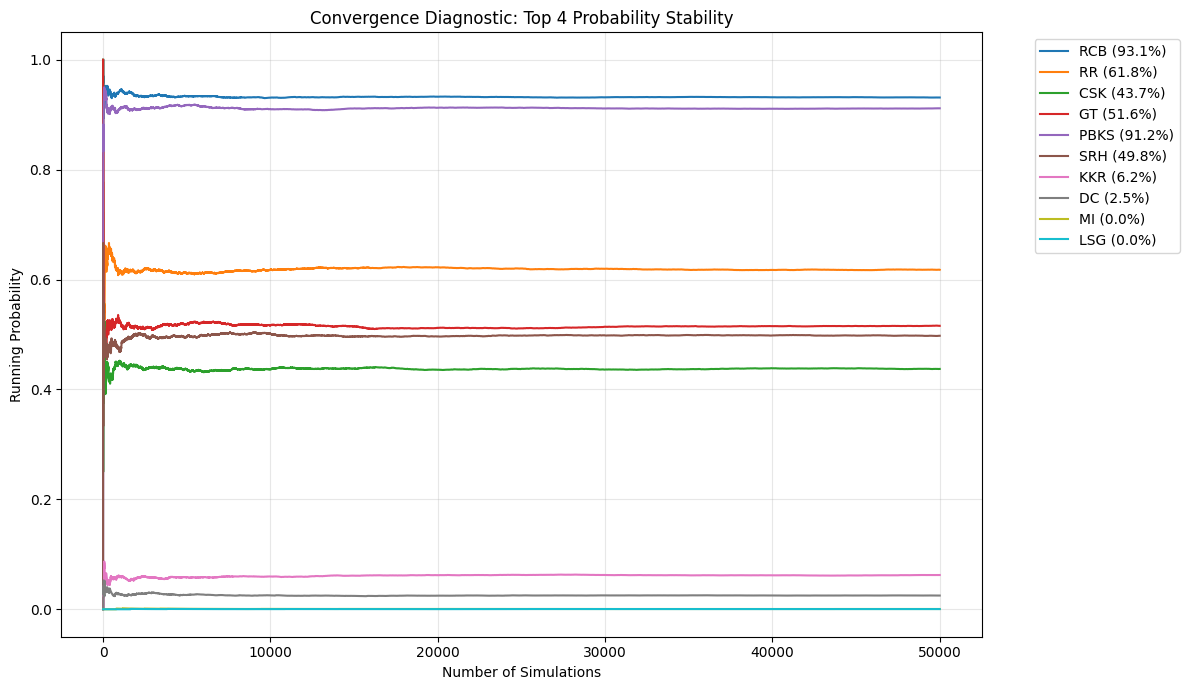

In [32]:
plt.figure(figsize=(12, 7))

standings_df["Qualified"] = standings_df["Rank"] <= 4

for team in standings_df["Team"].unique():

    team_data = standings_df[standings_df["Team"] == team].sort_values("Simulation").reset_index(drop=True)

    # Proper running probability (Monte Carlo convergence)
    running_prob = team_data["Qualified"].cumsum() / np.arange(1, len(team_data) + 1)

    plt.plot(running_prob.values, label=f"{team} ({running_prob.iloc[-1]:.1%})")

plt.title("Convergence Diagnostic: Top 4 Probability Stability")
plt.xlabel("Number of Simulations")
plt.ylabel("Running Probability")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 📊 Observations from Convergence Plot

The plot shows how the Top 4 qualification probabilities for each team evolve as the number of Monte Carlo simulations increases up to 50,000.

In the early phase of the simulation, probabilities fluctuate more noticeably due to the randomness inherent in match outcomes and the limited number of samples. As the number of simulations increases, these fluctuations gradually reduce, and the curves begin to stabilize.

After sufficient simulations, the probability estimates converge to steady values, indicating that the model has reached statistical stability. This suggests that the number of simulations used is adequate for reliable estimation of playoff probabilities.

Overall, the chart demonstrates the balance between early simulation uncertainty and long-run convergence of results in a probabilistic forecasting model.

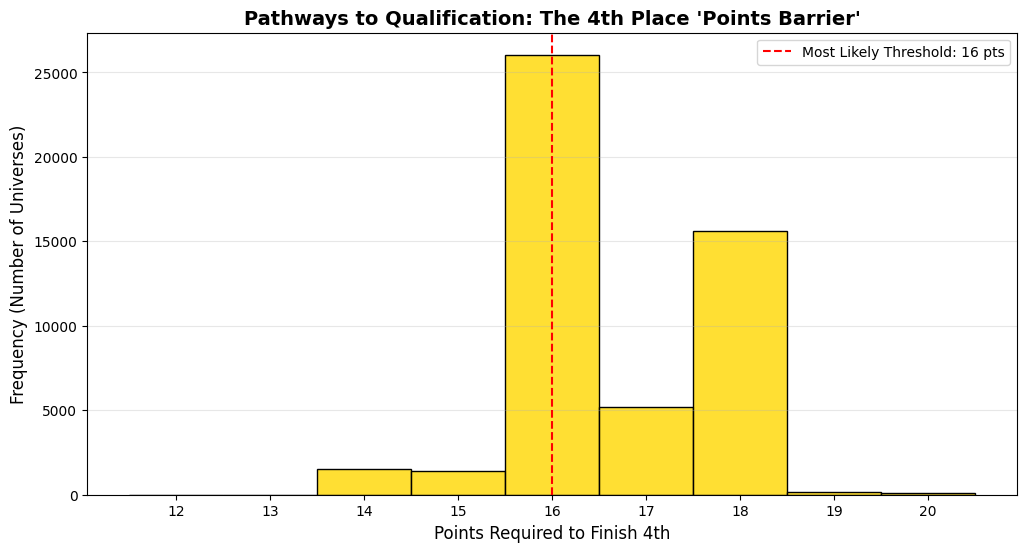

In [33]:
fourth_place_data = standings_df[standings_df["Rank"] == 4]

plt.figure(figsize=(12, 6))

# Plotting the histogram
sns.histplot(fourth_place_data["Final_Points"], 
             bins=range(int(fourth_place_data["Final_Points"].min()), 
                        int(fourth_place_data["Final_Points"].max()) + 2), 
             color="#FFD700", edgecolor="black", alpha=0.8, discrete=True)

# Add a vertical line for the 'Mode' (Most likely qualification threshold)
mode_pts = fourth_place_data["Final_Points"].mode()[0]
plt.axvline(mode_pts, color="red", linestyle="--", label=f"Most Likely Threshold: {mode_pts} pts")

plt.title("Pathways to Qualification: The 4th Place 'Points Barrier'", fontsize=14, fontweight='bold')
plt.xlabel("Points Required to Finish 4th", fontsize=12)
plt.ylabel("Frequency (Number of Universes)", fontsize=12)
plt.xticks(range(int(fourth_place_data["Final_Points"].min()), int(fourth_place_data["Final_Points"].max()) + 1))
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

# 📊 Observations: 4th Place Qualification Threshold

This histogram shows the distribution of final points scored by teams finishing in 4th place across all Monte Carlo simulations. It represents the range of “cutoff scenarios” required to qualify for the playoffs.

The spread of values indicates that the qualification threshold is not fixed and varies across different simulated tournament outcomes. This reflects the inherent uncertainty and competitiveness in the points table.

The red dashed line represents the most frequently occurring (mode) points total, which can be interpreted as the most likely qualification barrier in this season model.

A narrower distribution would indicate a more predictable qualification cutoff, while a wider spread suggests a highly competitive season where small differences in match outcomes significantly impact playoff qualification.

Overall, this visualization helps quantify the points stability required to reach the playoffs and highlights how volatile the 4th position can be across different tournament scenarios.


C:\Users\Ronak\AppData\Local\Temp\ipykernel_14284\3900931555.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=point_stats.index, y=point_stats["Qual_Prob"], palette="RdYlGn")


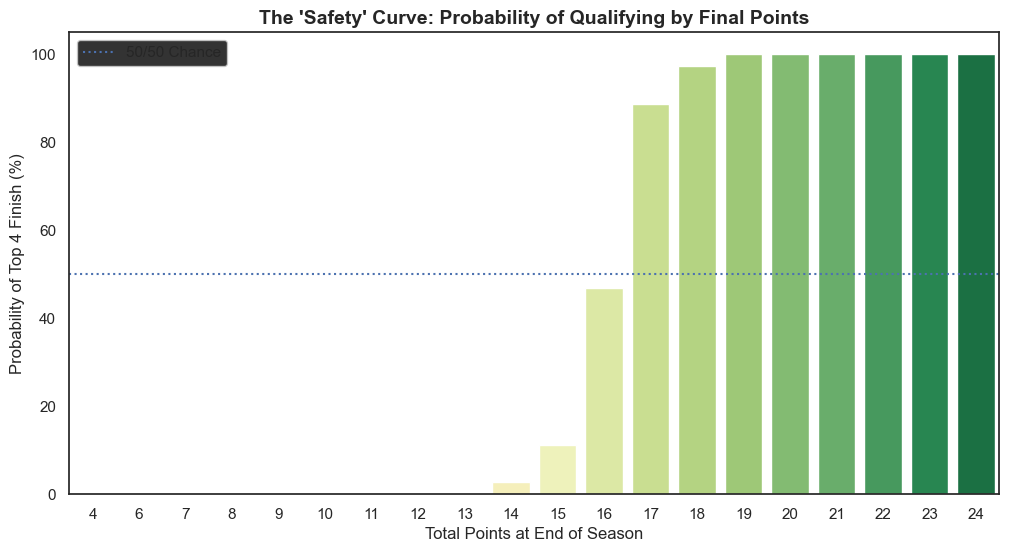

In [40]:
# Calculate the probability of being in Top 4 for each point total
point_stats = standings_df.groupby("Final_Points").agg( total_instances=("Qualified", "count"), qualified_instances=("Qualified", "sum"))
point_stats["Qual_Prob"] = (point_stats["qualified_instances"] / point_stats["total_instances"]) * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=point_stats.index, y=point_stats["Qual_Prob"], palette="RdYlGn")

plt.title("The 'Safety' Curve: Probability of Qualifying by Final Points", fontsize=14, fontweight="bold")
plt.xlabel("Total Points at End of Season", fontsize=12)
plt.ylabel("Probability of Top 4 Finish (%)", fontsize=12)
plt.axhline(50, color="gray", linestyle=":", label="50/50 Chance")
plt.legend()
plt.show()

# 📊 Observations: The “Safety Curve” of Qualification

This plot shows the probability of a team finishing in the Top 4 based on its final points total across all Monte Carlo simulations. It captures how “safe” a given points total is for playoff qualification.

Lower point totals correspond to highly uncertain qualification chances, where small variations in match outcomes significantly impact standings. As points increase, the probability of qualification rises steadily, eventually approaching near certainty for top-performing teams.

The 50% reference line helps identify the “tipping point,” where a team is equally likely to qualify or miss out. This region represents the most competitive zone in the points table, where playoff qualification is highly sensitive to net run rate and marginal results.

Overall, the curve quantifies the relationship between performance (points) and qualification security, highlighting the nonlinear nature of playoff qualification in a competitive league format.

<Figure size 1200x800 with 0 Axes>

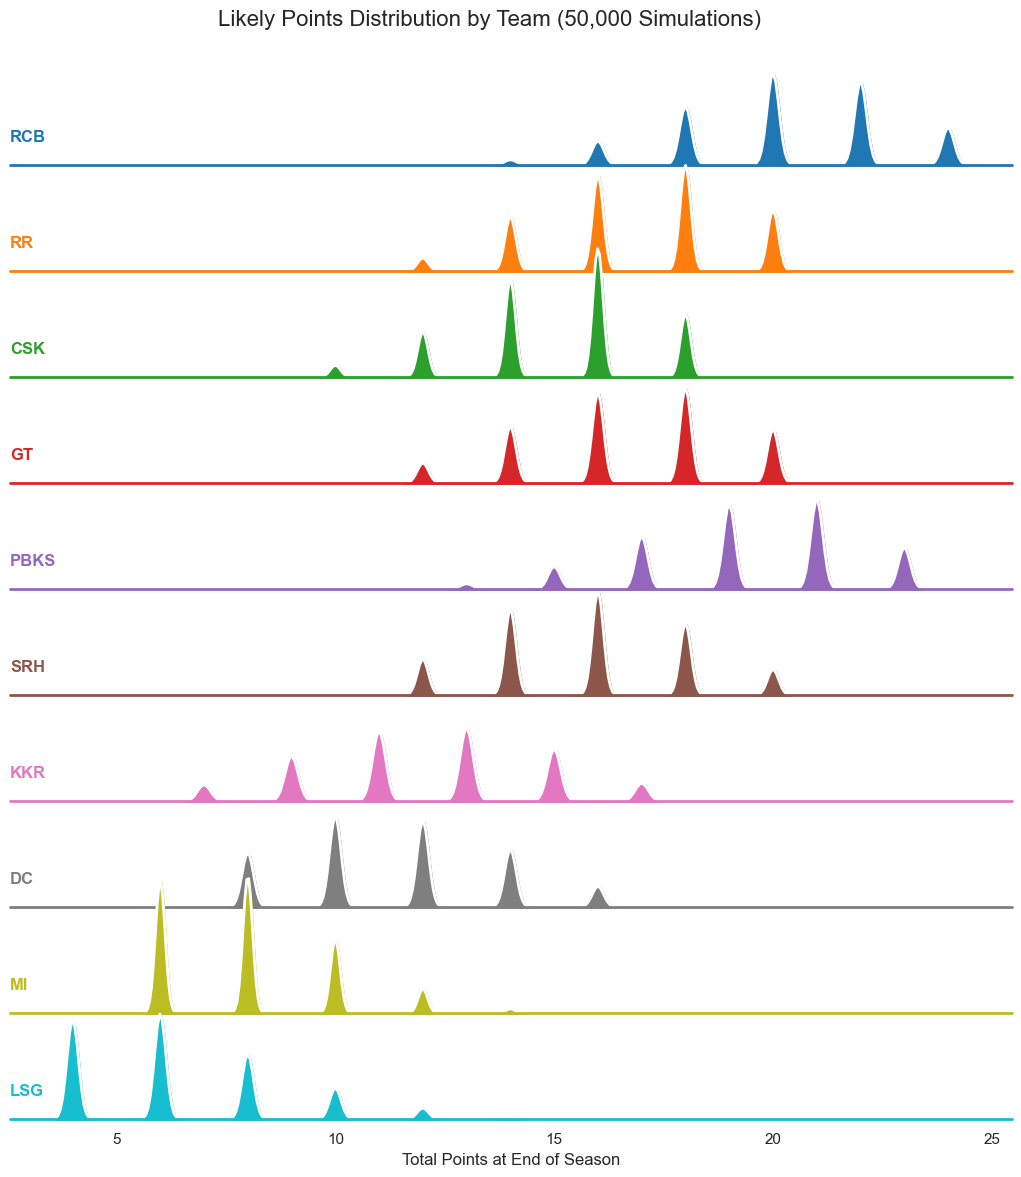

In [37]:
# Set the aesthetic style
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Create the Ridge Plot
plt.figure(figsize=(12, 8))
g = sns.FacetGrid(standings_df, row="Team", hue="Team", aspect=9, height=1.2, palette="tab10")

# Draw the densities
g.map(sns.kdeplot, "Final_Points", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "Final_Points", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Add a horizontal line for each team
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# Custom labeling
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)

g.map(label, "Final_Points")

# Final formatting
g.fig.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.xlabel("Total Points at End of Season")
plt.suptitle("Likely Points Distribution by Team (50,000 Simulations)", fontsize=16)
plt.show()

# 📊 Observations: Team-wise Points Distribution (Ridge Plot)

This ridge plot visualizes the distribution of final points for each team across all Monte Carlo simulations. It provides a comparative view of how consistently each team performs in different simulated season outcomes.

Teams with narrower distributions indicate more stable performance, where their final points remain relatively consistent across simulations. In contrast, wider distributions reflect higher volatility, meaning the team’s final standing is more sensitive to match outcomes and tournament dynamics.

The overlap between distributions highlights the level of competition between teams. Significant overlap suggests closely matched teams competing for similar points ranges, making playoff qualification highly competitive.

Overall, this visualization helps understand not just expected performance, but also the uncertainty and variability in each team’s season outcome under the simulation model.

In [41]:
# Group by Team and calculate statistics
stats_summary = standings_df.groupby("Team")["Final_Points"].agg([
    ("Avg Points", 'mean'),
    ("Most Likely (Mode)", lambda x: x.mode()[0]),
    ("Floor (5th Percentile)", lambda x: x.quantile(0.05)),
    ("Ceiling (95th Percentile)", lambda x: x.quantile(0.95)),
    ("Volatility (Std Dev)", "std")
]).sort_values(by="Avg Points", ascending=False)

print(stats_summary)

      Avg Points  Most Likely (Mode)  Floor (5th Percentile)  \
Team                                                           
RCB     20.24448                  20                    16.0   
PBKS    19.39596                  21                    15.0   
RR      16.89504                  18                    14.0   
GT      16.66812                  18                    12.0   
SRH     15.78400                  16                    12.0   
CSK     15.07288                  16                    12.0   
KKR     12.11924                  13                     7.0   
DC      11.35684                  10                     8.0   
MI       8.01868                   8                     6.0   
LSG      6.44476                   6                     4.0   

      Ceiling (95th Percentile)  Volatility (Std Dev)  
Team                                                   
RCB                        24.0              2.390084  
PBKS                       23.0              2.421118  
RR     

# 📊 Observations: Season Statistics Summary

This table summarizes the distribution of final points for each team across all Monte Carlo simulations. It captures both central tendency and variability in team performance.

The **average points** represent the expected performance of each team over the simulated season, while the **mode (most likely outcome)** indicates the most frequently occurring final points total.

The **5th and 95th percentiles** define the lower and upper bounds of realistic outcomes, helping to understand best-case and worst-case season scenarios for each team.

The **standard deviation (volatility)** measures how inconsistent a team’s performance is across simulations. Higher volatility indicates greater uncertainty in final standings, while lower volatility suggests more stable and predictable performance.

Overall, this summary provides a compact statistical view of team strength, consistency, and uncertainty within the simulation framework.